# **SKIN DISORDER PREDICTION**

 Project ID: PRCP-1027

 Domain: Healthcare

 Objective: To develop a machine learning model that can accurately predict and classify different types of skin disorders using clinical and dermatological features.

# INTRODUCTION


Skin disorders are common health conditions that can affect people of all ages. Early and accurate diagnosis is important for effective treatment. This project uses Machine Learning techniques to analyze dermatological features and predict different types of skin disorders, helping support faster and more accurate healthcare decisions.


# PROBLEM STATEMENT


1. Analyze the skin disorder dataset and understand the characteristics of dermatological features.

2. Perform data preprocessing, exploratory data analysis (EDA), and feature engineering.

3. Build and evaluate multiple machine learning models for skin disorder classification.

4. Compare model performances and identify the best-performing model.

5. Develop a predictive system for accurate skin disorder classification.

6. Provide healthcare insights and recommendations based on the analysis.


# 1. IMPORTS

In [ ]:
#core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Boosting
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 2. LOAD DATASETS



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI-Projects/PRCP-1027-Skin Disorder/Data/dataset_35_dermatology.csv')

df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


# 3. DATA UNDERSTANDING

In [ ]:
#Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

In [ ]:
#Stats
df.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [ ]:
df.shape

(366, 35)

# 4. Data Preprocessing

In [ ]:
# Missing Values
df.isnull().sum()

,0
erythema,0
scaling,0
definite_borders,0
itching,0
koebner_phenomenon,0
polygonal_papules,0
follicular_papules,0
oral_mucosal_involvement,0
knee_and_elbow_involvement,0
scalp_involvement,0


In [ ]:
# cheking duplicate records
df.duplicated().sum()

np.int64(0)

# 5. EDA

# 5.1 Numerical Distribution

In [ ]:
df['class'].value_counts()

,count
class,
1,112
3,72
2,61
5,52
4,49
6,20


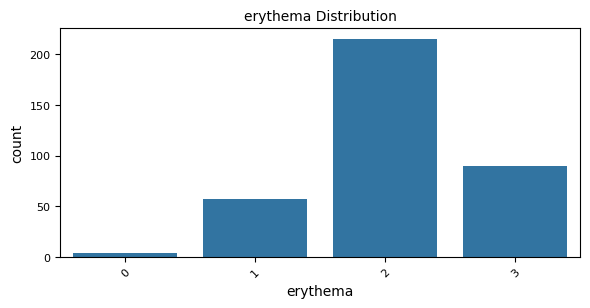

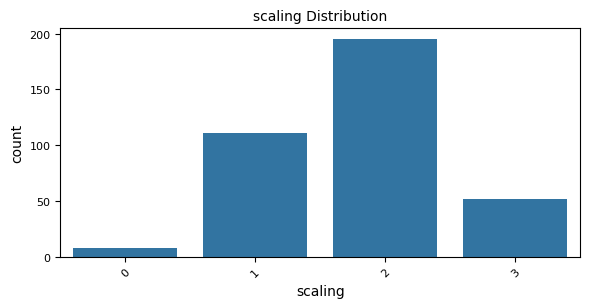

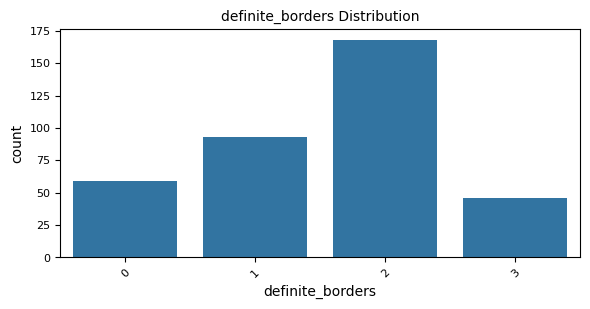

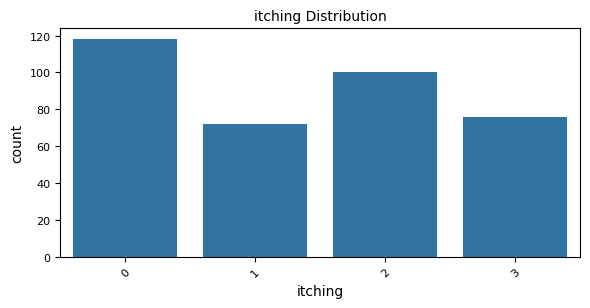

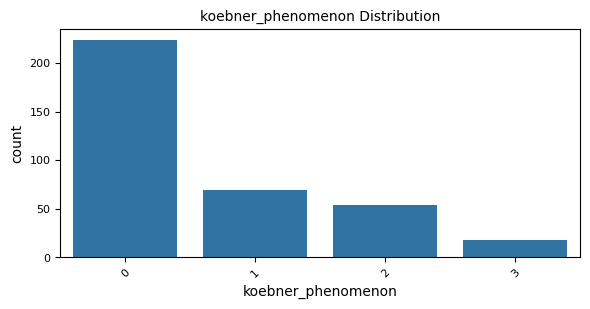

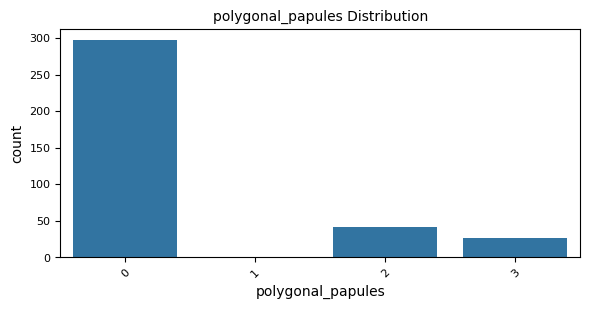

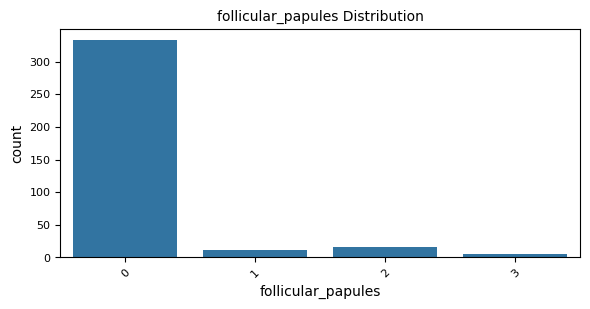

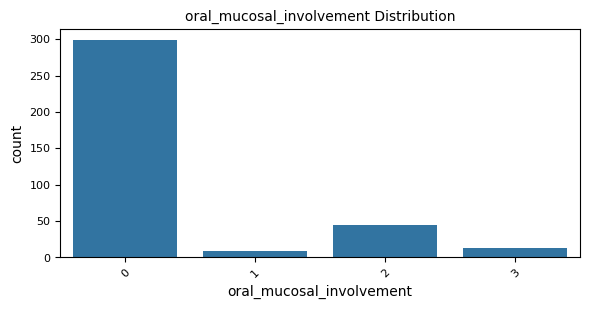

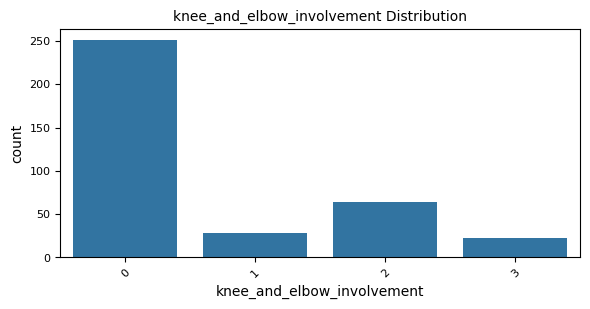

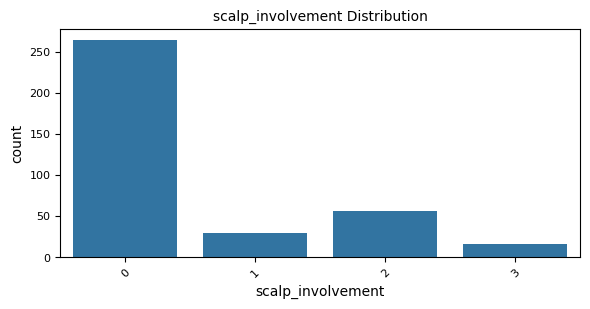

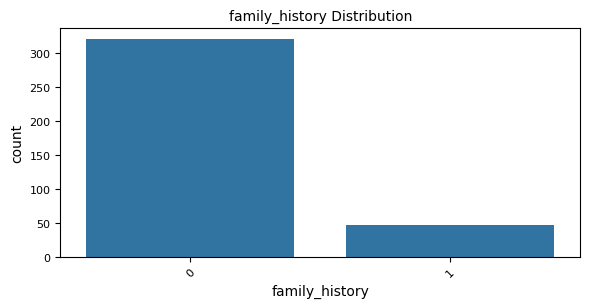

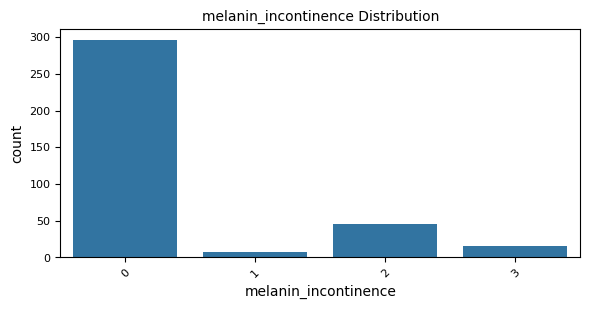

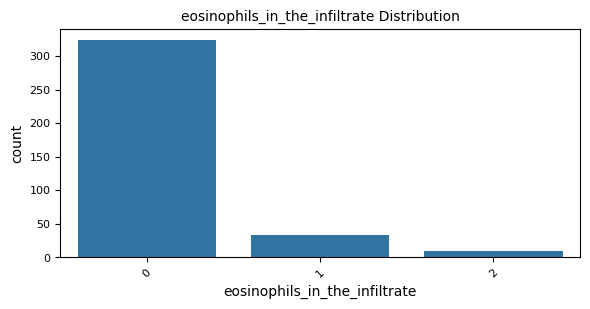

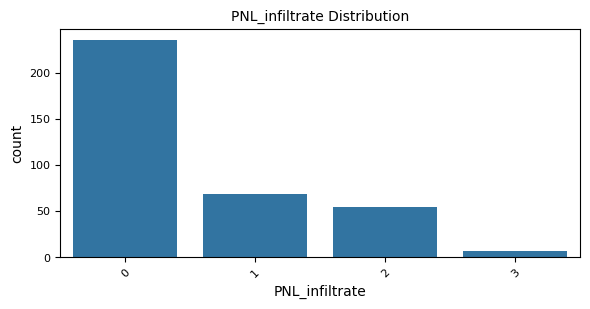

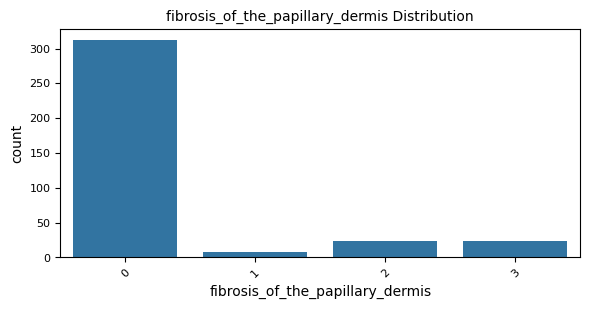

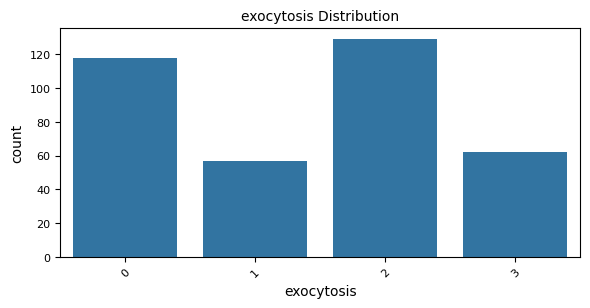

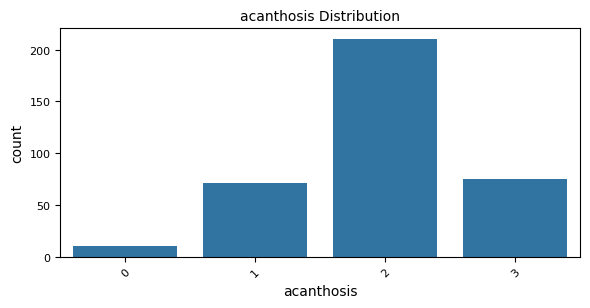

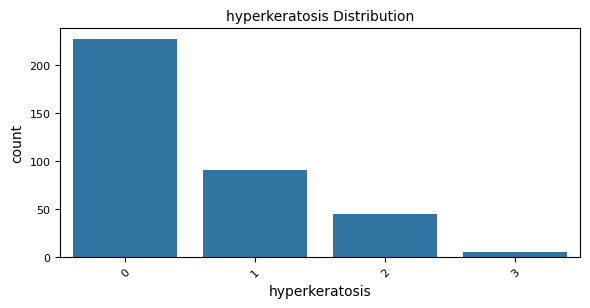

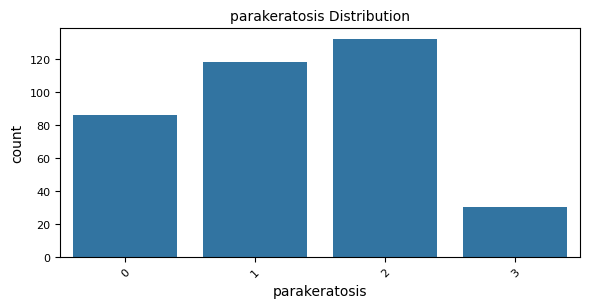

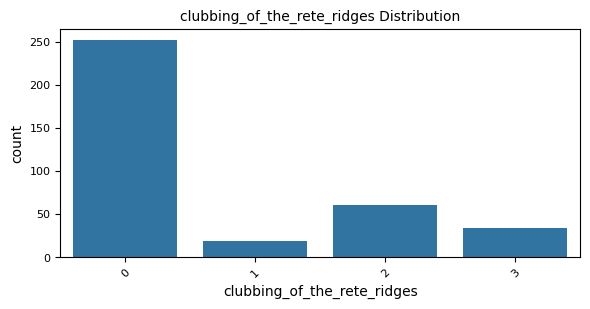

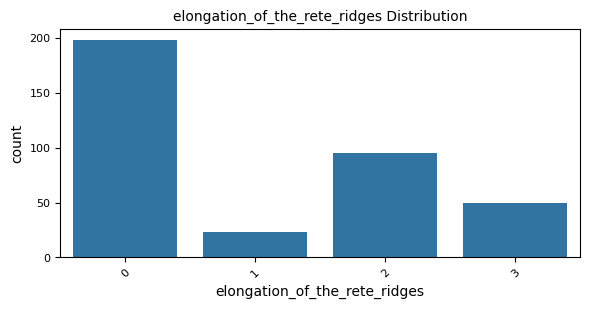

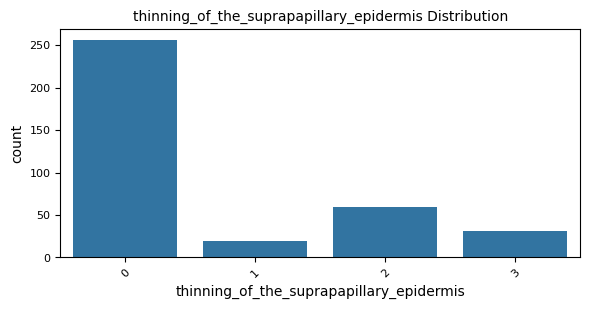

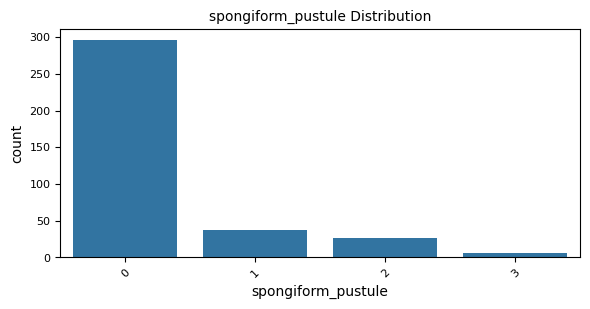

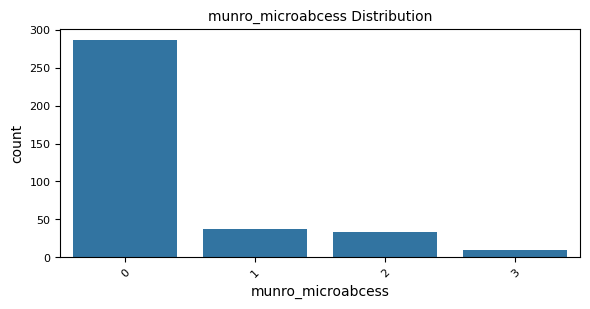

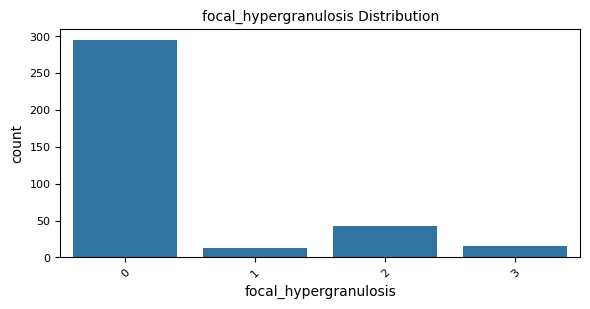

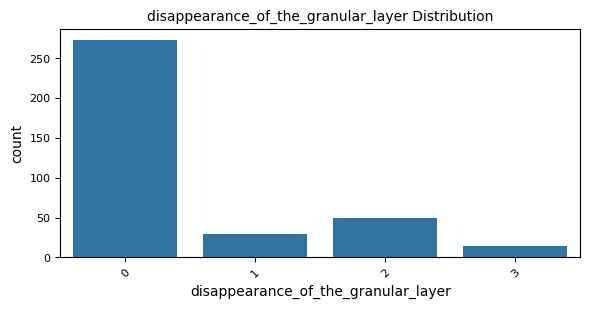

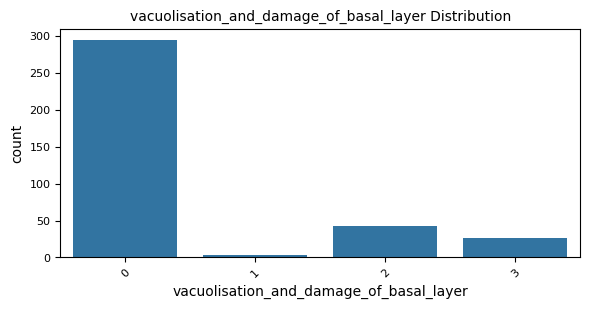

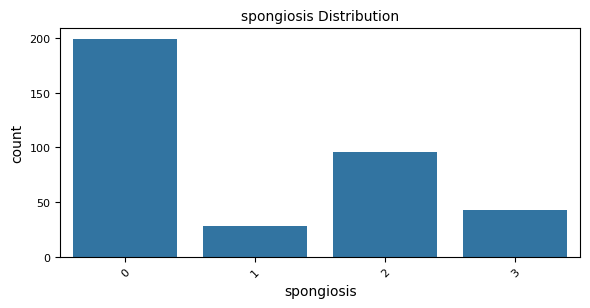

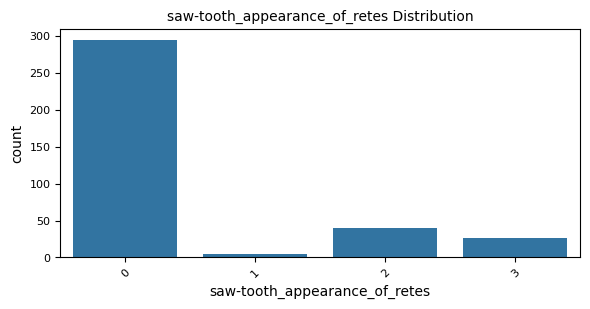

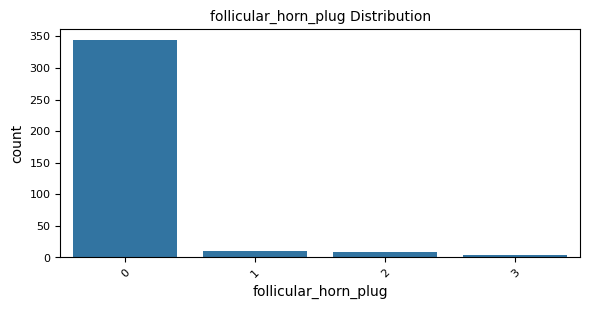

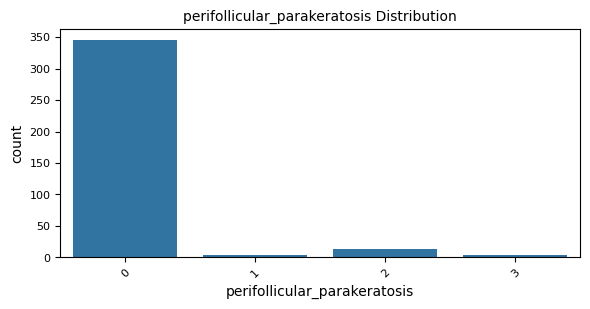

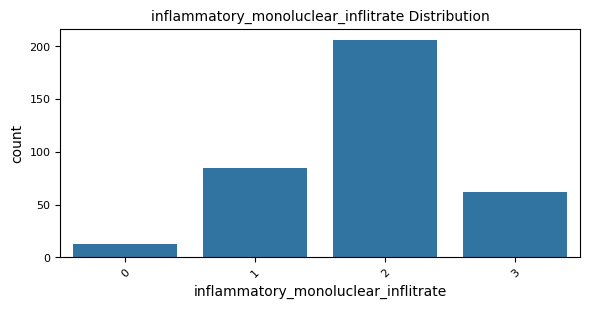

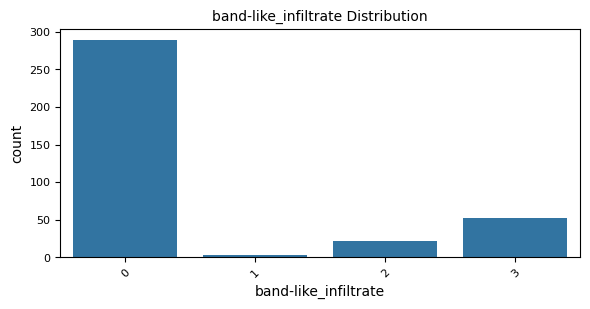

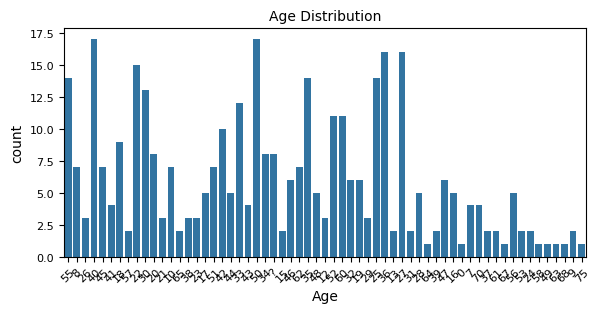

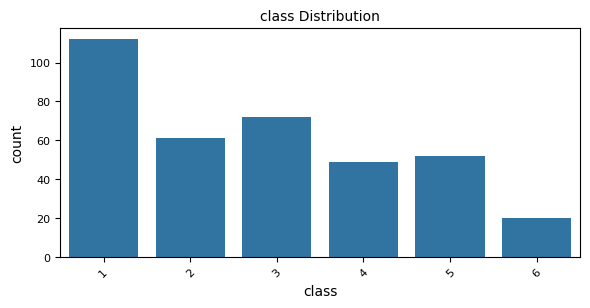

In [ ]:
for col in df.columns:

    plt.figure(figsize=(6,3.5))

    sns.countplot(x=col, data=df)

    plt.title(f"{col} Distribution", fontsize=10)

    plt.xticks(rotation=45, fontsize=8)

    plt.yticks(fontsize=8)

    plt.tight_layout()

    plt.subplots_adjust(bottom=0.25)

    plt.show()

    print("\n")   # Adds a blank line between graphs

# 5.2 Correlation Heatmap

/tmp/ipykernel_1093/2528441398.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


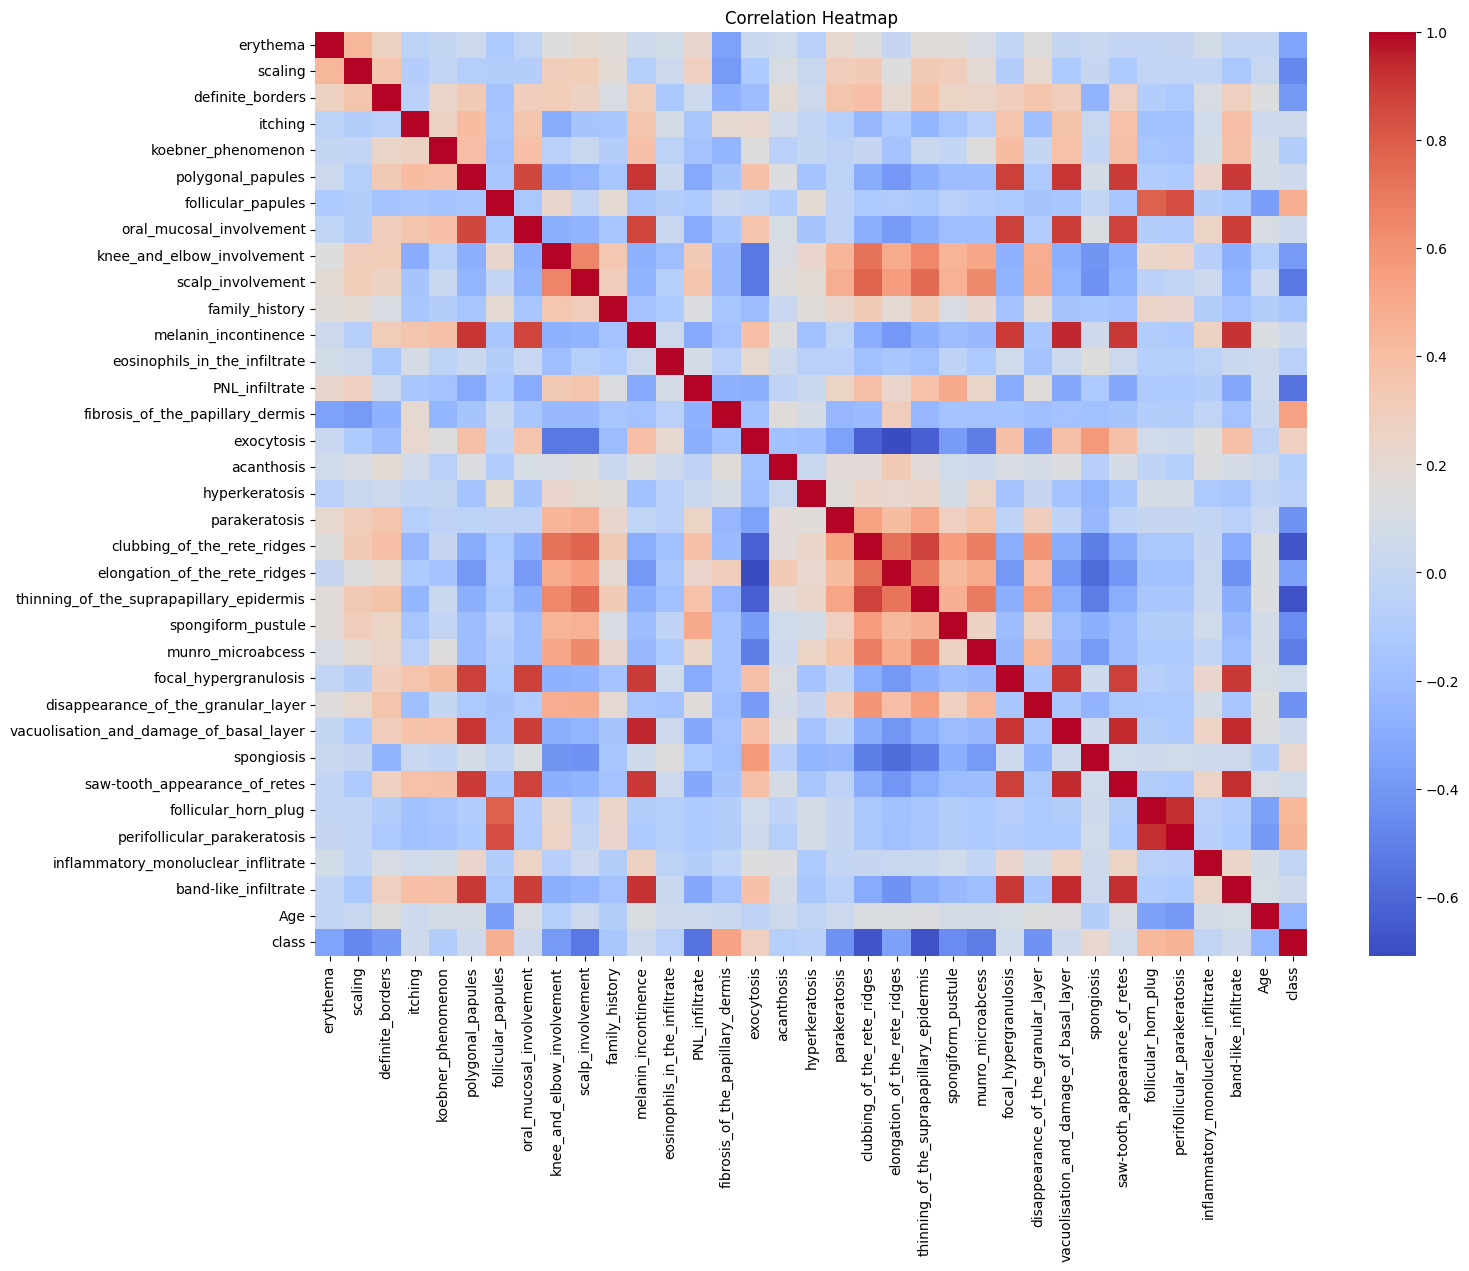

In [44]:
# Replace missing values represented by '?'
df.replace('?', np.nan, inplace=True)

# Convert Age to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Fill missing Age values
df['Age'].fillna(df['Age'].median(), inplace=True)

# Correlation Heatmap
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

# 5.3 Feature VS Target Analysis

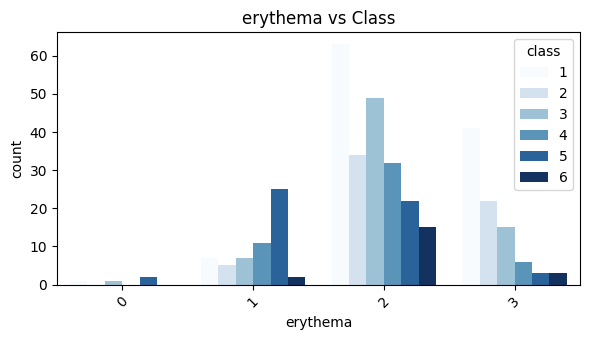

/n


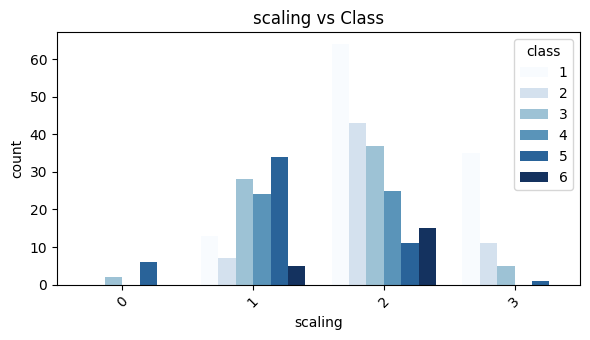

/n


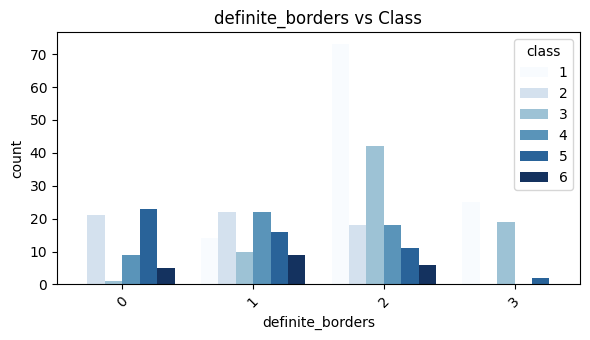

/n


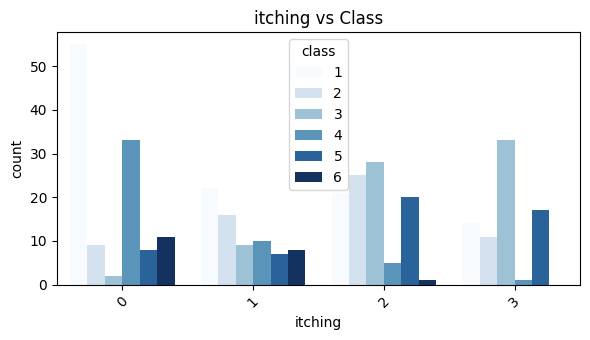

/n


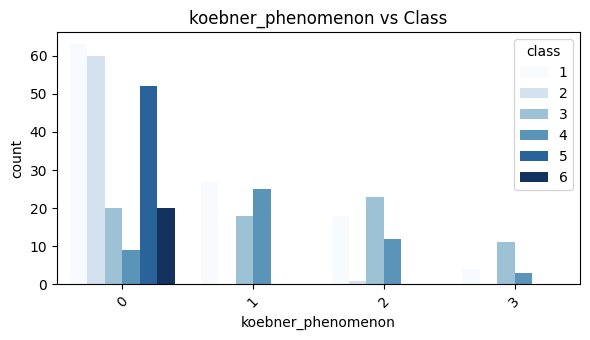

/n


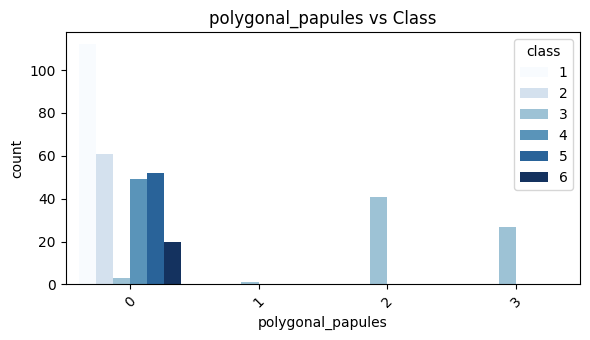

/n


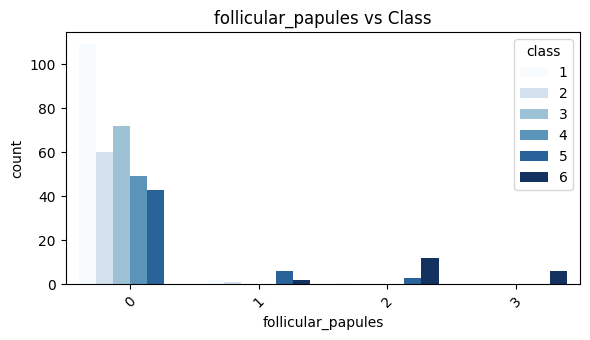

/n


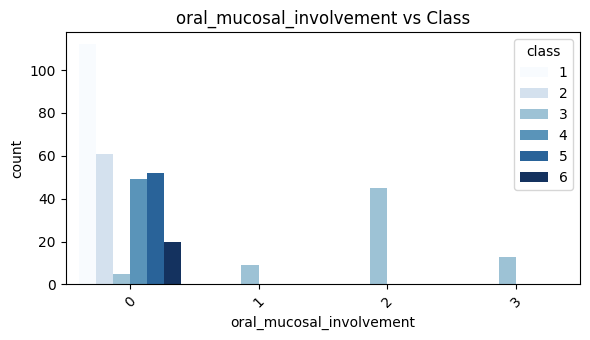

/n


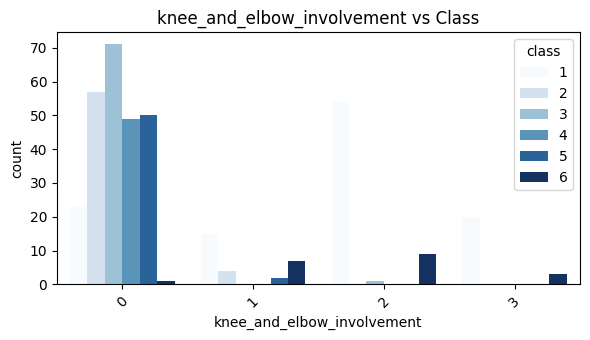

/n


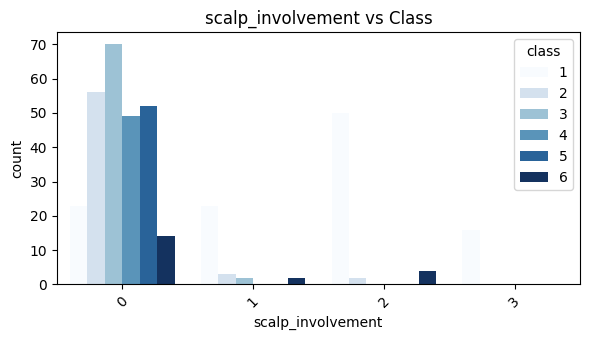

/n


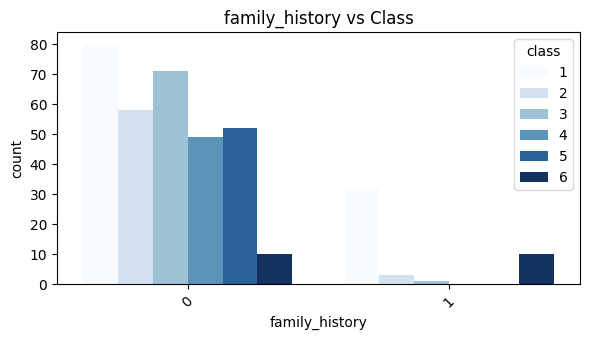

/n


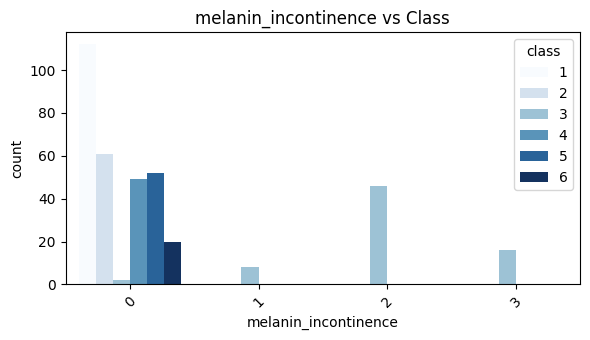

/n


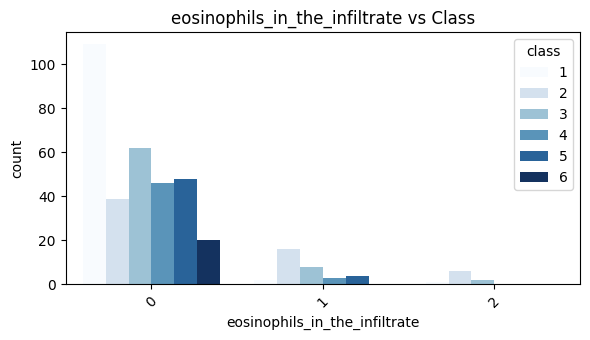

/n


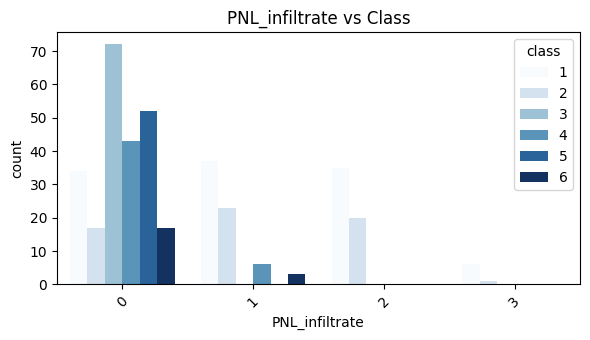

/n


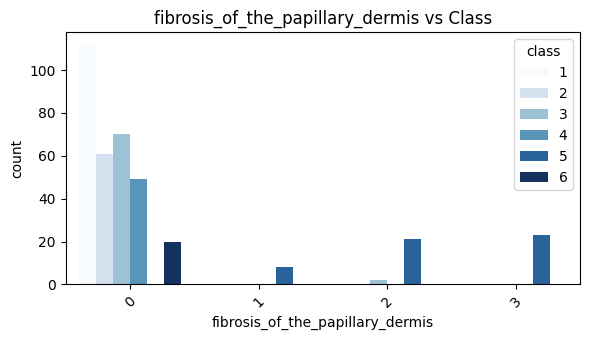

/n


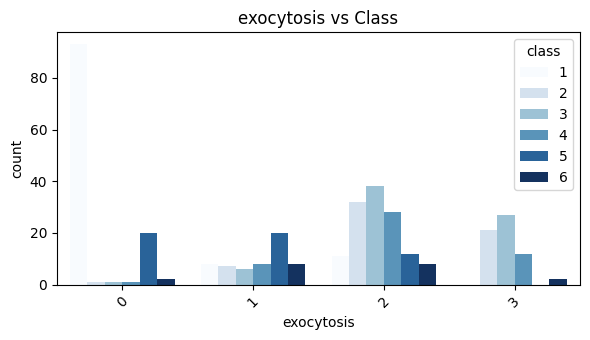

/n


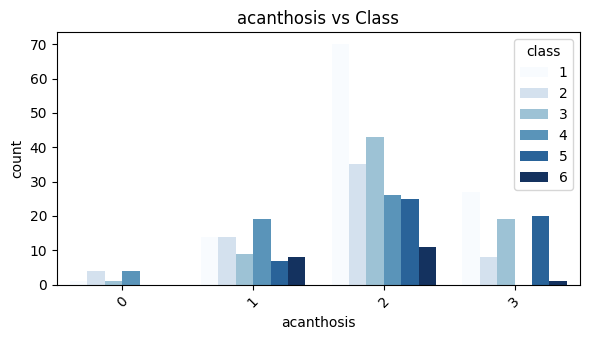

/n


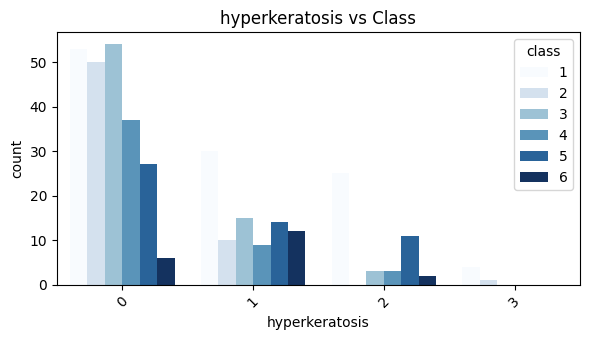

/n


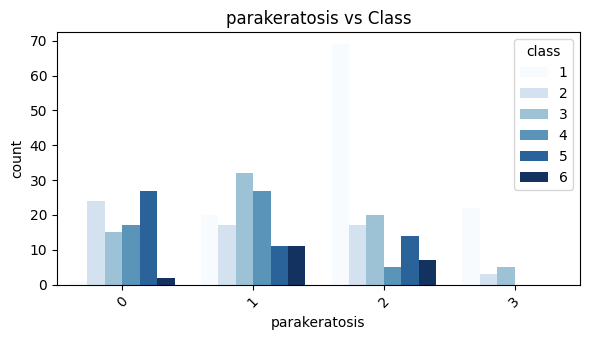

/n


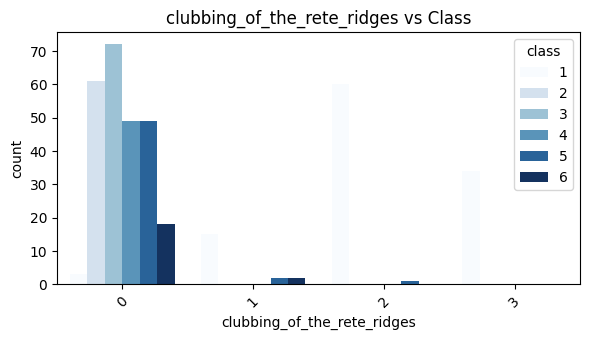

/n


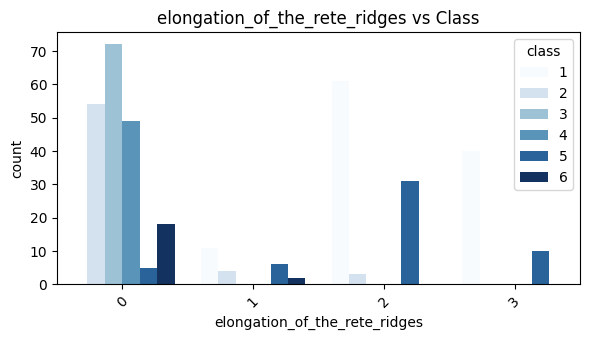

/n


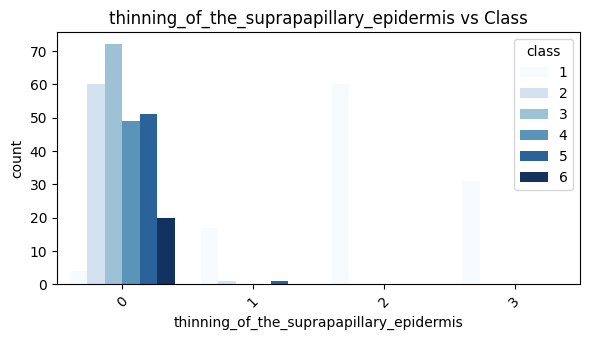

/n


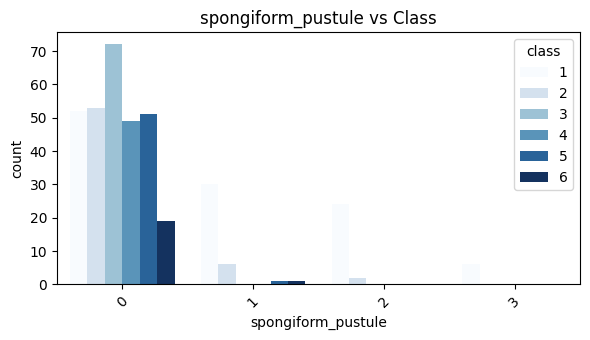

/n


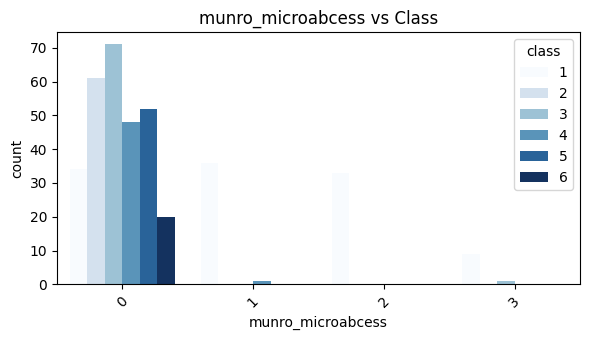

/n


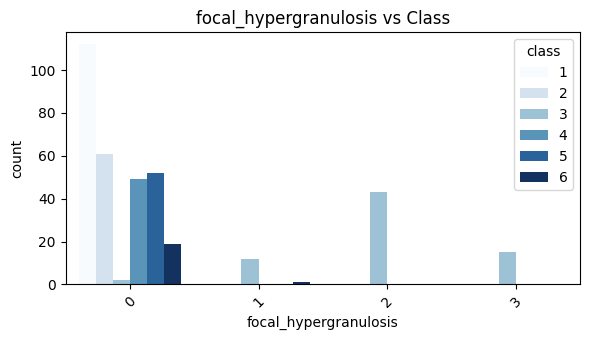

/n


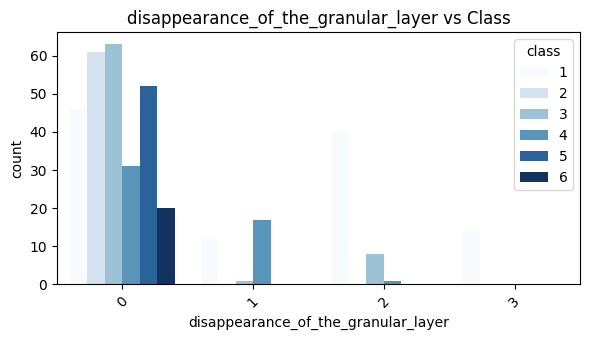

/n


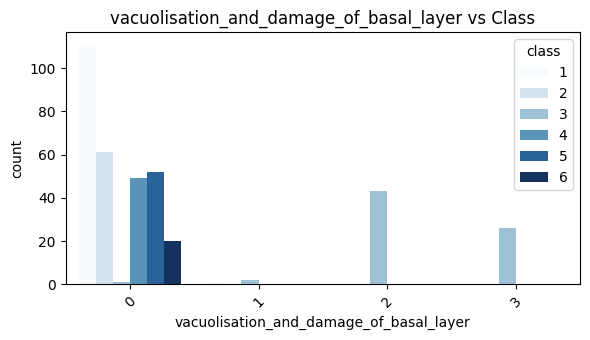

/n


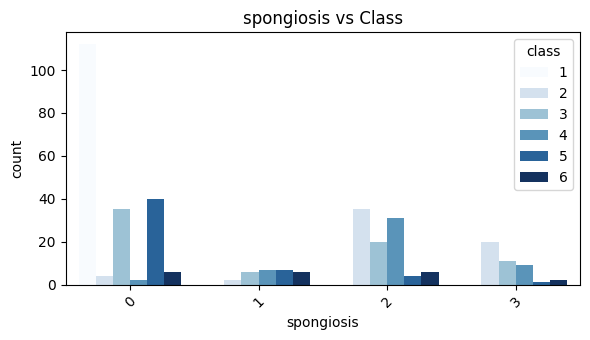

/n


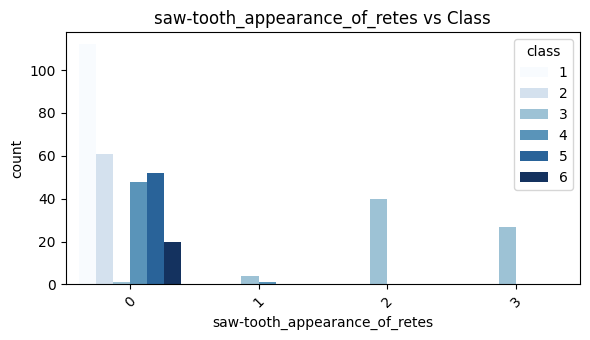

/n


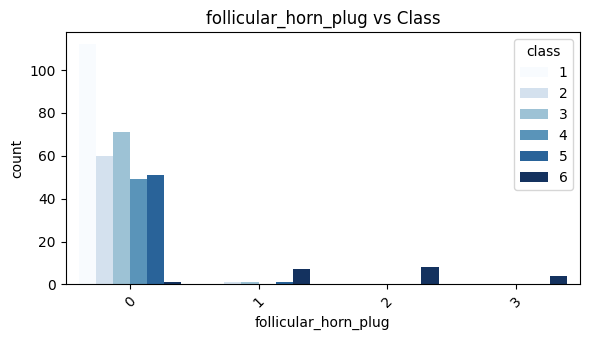

/n


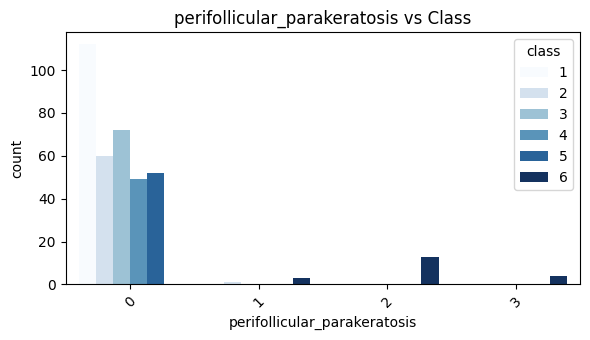

/n


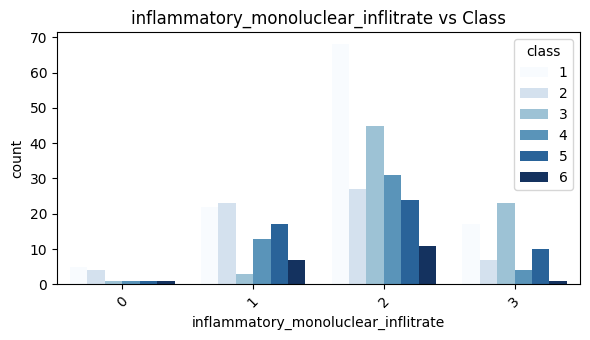

/n


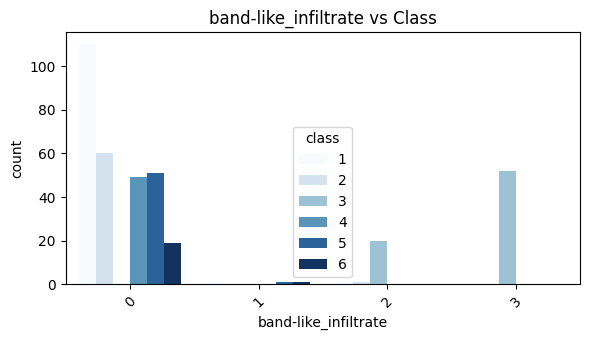

/n


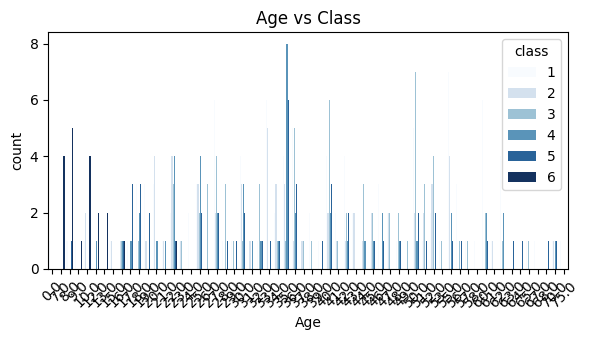

/n


In [ ]:
feature_cols = [col for col in df.columns if col not in ['class']]

for col in feature_cols:

    plt.figure(figsize=(6,3.5))

    sns.countplot(
        x=col,
        hue='class',
        data=df,
        palette='Blues'
    )

    plt.title(f"{col} vs Class")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

    print("/n")

# 6. FEATURE ENGINEERING

# 6.1 Handle Missing Values

In [45]:
# Handle Missing Values
df.replace('?', np.nan, inplace=True)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_1093/711385926.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


# 6.2 Separate Features And Target

In [46]:
# Separate Features And Target
X = df.drop('class', axis=1)
y = df['class']

# 6.3 Label Encoder

In [47]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['class'])

In [48]:
X = df.drop('class', axis=1)

# 6.4 Train Test Split

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# 6.5 Scaling

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. MODEL BUILDING

# Model Dictionary

In [51]:
# Scaled data (for some models)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
"""models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}"""

'models = {\n    "Logistic Regression": LogisticRegression(),\n    "Decision Tree": DecisionTreeClassifier(),\n    "Random Forest": RandomForestClassifier(),\n    "Gradient Boosting": GradientBoostingClassifier(),\n    "SVM": SVC(probability=True),\n    "KNN": KNeighborsClassifier(),\n    "Naive Bayes": GaussianNB(),\n    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric=\'logloss\')\n}'

# 1. Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9864864864864865


# 2. Decision Tree

In [54]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.9864864864864865


# 3. Random Forest

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9864864864864865


# 4. Gradient Boosting

In [56]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)
print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 1.0


# 5. XGBoost

In [57]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.9864864864864865


# 6. Support Vector Machine (SVM)

In [58]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.9864864864864865


# 7. K-Nearest Neighbors (KNN)

In [59]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.9864864864864865


# 8. Naive Bayes

In [60]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:", nb_acc)


Naive Bayes Accuracy: 0.9054054054054054


# 8. MODEL EVALUATION

In [61]:
from sklearn.metrics import roc_auc_score, confusion_matrix

def print_metrics(name, y_test, y_pred, y_prob=None):
    print(f"\n{name}")
    print("="*40)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

    if y_prob is not None:
        print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       0.90      1.00      0.95         9
           2       1.00      1.00      1.00        13
           3       1.00      0.88      0.93         8
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74



# 9. Store Results

In [63]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'SVM',
    'KNN',
    'XGBoost',
    'Naive Bayes'
]

accuracy = [
    lr_acc,
    dt_acc,
    rf_acc,
    gb_acc,
    svm_acc,
    knn_acc,
    xgb_acc,
    nb_acc
]

# 10. Create Comparison Table

In [64]:
comparison = pd.DataFrame({

    'Models': models,

    'Accuracy': accuracy

})

comparison

,Models,Accuracy
0,Logistic Regression,0.986486
1,Decision Tree,0.986486
2,Random Forest,0.986486
3,Gradient Boosting,1.000000
4,SVM,0.986486
5,KNN,0.986486
6,XGBoost,0.986486
7,Naive Bayes,0.905405


In [65]:
# Sort Result
comparison.sort_values(
    by='Accuracy',
    ascending=False
)

,Models,Accuracy
3,Gradient Boosting,1.000000
0,Logistic Regression,0.986486
1,Decision Tree,0.986486
2,Random Forest,0.986486
4,SVM,0.986486
5,KNN,0.986486
6,XGBoost,0.986486
7,Naive Bayes,0.905405


# 10.1 Comparison Graph

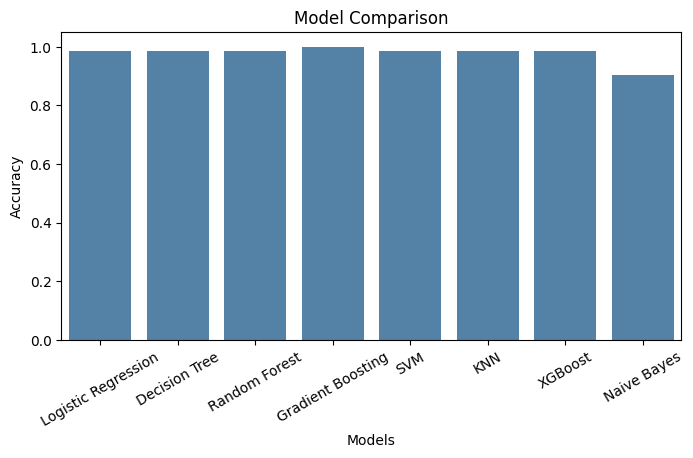

In [66]:
plt.figure(figsize=(8,4))
sns.barplot(
    x='Models',
    y='Accuracy',
    data=comparison,
    color='steelblue'
)

plt.title('Model Comparison')
plt.xticks(rotation=30)
plt.show()

# 11. Best Model

In [67]:
best_model = comparison.loc[
    comparison['Accuracy'].idxmax()
]
best_model

,3
Models,Gradient Boosting
Accuracy,1.0


# 11.1. BEST MODEL SELECTION

Among all the machine learning models tested, Gradient Boosting achieved the highest accuracy score. Therefore, it was selected as the best-performing model for Skin Disorder Prediction.

Gradient Boosting is an ensemble learning algorithm that combines multiple weak learners (decision trees) sequentially. Each new tree attempts to correct the errors made by the previous trees, resulting in improved predictive performance.

The model demonstrated superior accuracy, better generalization capability, and effective handling of complex relationships between dermatological features and disease classes. Compared to other models such as Logistic Regression, Decision Tree, Random Forest, SVM, KNN, Naive Bayes, and XGBoost, Gradient Boosting provided the most reliable classification results on the test dataset.

### Why Gradient Boosting?

**Accuracy:** 1.00 (100%)

1. Gradient Boosting achieved the highest accuracy among all the tested models.
  2. It improves prediction performance by correcting the errors of previous decision trees and effectively captures complex patterns in the dataset. Hence, it was selected as the best model for this project.


# 12. Confusion Matrix

In [68]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, gb_pred)
cm

array([[31,  0,  0,  0,  0,  0],
       [ 0,  9,  0,  0,  0,  0],
       [ 0,  0, 13,  0,  0,  0],
       [ 0,  0,  0,  8,  0,  0],
       [ 0,  0,  0,  0, 10,  0],
       [ 0,  0,  0,  0,  0,  3]])

# 12.1  Confusion Matrix Visualization

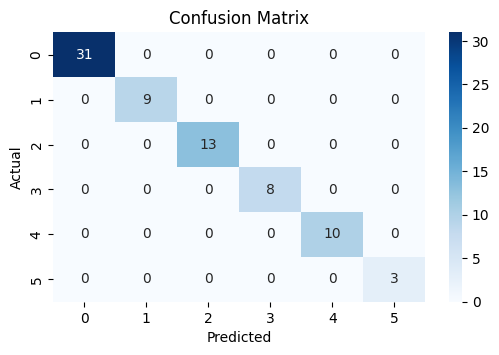

In [70]:
plt.figure(figsize=(6,3.5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 13. FEATURE IMPORTANCE

In [71]:
feature_importance = pd.DataFrame({
'Feature':X.columns,
'Importance':gb.feature_importances_
})
feature_importance

,Feature,Importance
0,erythema,3.726108e-03
1,scaling,1.070193e-03
2,definite_borders,7.188488e-03
3,itching,3.405097e-02
4,koebner_phenomenon,5.632761e-02
5,polygonal_papules,1.801264e-01
6,follicular_papules,3.078247e-03
7,oral_mucosal_involvement,3.510533e-03
8,knee_and_elbow_involvement,1.271096e-03
9,scalp_involvement,2.621278e-06


# 13.1 Top 10 Important Features

In [72]:
feature_importance = feature_importance.sort_values(
    by='Importance',
   ascending=False
)
feature_importance.head(10)

,Feature,Importance
21,thinning_of_the_suprapapillary_epidermis,0.236482
5,polygonal_papules,0.180126
14,fibrosis_of_the_papillary_dermis,0.157012
30,perifollicular_parakeratosis,0.070247
27,spongiosis,0.068995
4,koebner_phenomenon,0.056328
32,band-like_infiltrate,0.050457
13,PNL_infiltrate,0.044977
3,itching,0.034051
19,clubbing_of_the_rete_ridges,0.018721


# 10.2 Feature Importance Graph

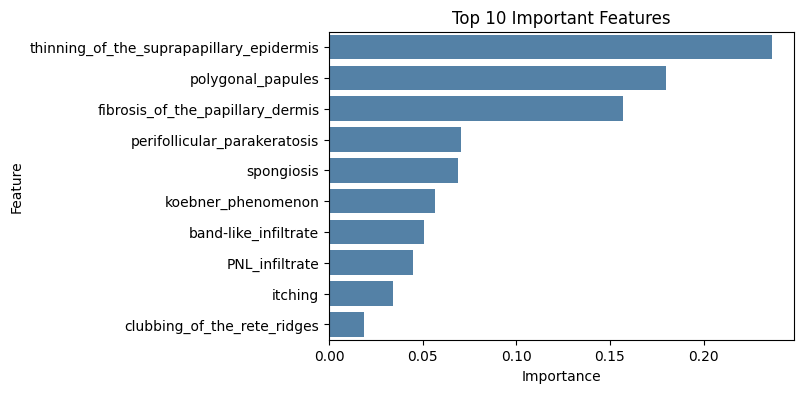

In [73]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10),
    color='steelblue'
)
plt.title("Top 10 Important Features")
plt.show()

# 14. SAMPLE PREDICTION

In [74]:
sample = X_test[0].reshape(1,-1)
prediction = gb.predict(sample)
print("Predicted Class:", prediction[0])

Predicted Class: 0


# 15. CHALLENGES FACED

1. Handling missing values in the Age feature.
2. Managing multi-class classification with six disease categories.
3. Identifying the most important predictive features.
4. Comparing multiple machine learning models to select the best one.
5. Understanding medical and dermatological attributes in the dataset.

# 16. SUGGESTIONS TO HOSPITAL

1. Implement AI-based screening systems for early skin disease detection.
2. Encourage regular dermatological checkups for high-risk patients.
3. Maintain digital patient records for better disease monitoring.
4. Use predictive analytics to support clinical decision-making.
5. Promote awareness programs for early diagnosis and treatment.

# 17. CONCLUSION



1. Successfully developed a Skin Disorder Prediction System using machine learning.

2. Performed data preprocessing, EDA, and feature engineering on the dataset.

3. Trained and evaluated multiple machine learning models.

4. Gradient Boosting achieved the highest accuracy of 1.00 (100%).

5. Gradient Boosting was selected as the final model for prediction.

6. The model can help in early detection and classification of skin disorders.

7. Machine learning can support healthcare professionals in making faster and more accurate decisions.
